In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import sklearn.pipeline
import sklearn.preprocessing

import torch
from IPython.core.interactiveshell import InteractiveShell
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.svm import OneClassSVM

# from utils.norm import TanhNormalizer
from dataset.dataset import Dataset
from models.autoencoder.vae import VariationalAutoencoder
from utils.metrics import Plot

In [2]:
if InteractiveShell.initialized():
    ipython = InteractiveShell.instance()
    if 'autoreload' not in globals():
        ipython.run_line_magic('load_ext', 'autoreload')
        ipython.run_line_magic('autoreload', '2')
        autoreload = True

In [3]:
dataset_path = 'data/2018/combined/100000.parquet'
dataset = Dataset.from_file(path=dataset_path, random_state=7)
dataset.encode_labels()
dataset.normalize(algorithm=sklearn.pipeline.Pipeline(
    steps=[
        ('qt', sklearn.preprocessing.QuantileTransformer()),
        ('minmax', sklearn.preprocessing.MinMaxScaler())
    ], verbose=False)
)

In [7]:
train_dataset, test_dataset = dataset.split(test_size=10)
benign, attacks = train_dataset.label_partition(labels=[1], binary=True)

benign_train, benign_test, benign_val = benign.split(val=True, test_size=40, val_size=10)

batch = 16

benign_train_dl = benign_train.create_data_loader(include_label=False, batch_size=batch, shuffle=True)
benign_test_dl = benign_test.create_data_loader(include_label=False, batch_size=batch, shuffle=False)
benign_val_dl = benign_val.create_data_loader(include_label=False, batch_size=batch, shuffle=False)

attacks_train, attacks_test, attacks_val = attacks.split(val=True, test_size=40, val_size=10)

attacks_train_dl = attacks_train.create_data_loader(batch_size=2)
attacks_test_dl = attacks_test.create_data_loader(batch_size=2)
attacks_val_dl = attacks_val.create_data_loader(batch_size=2)

In [8]:
model = VariationalAutoencoder(hidden_layers=[128, 64, 32], latent_dim=8).to('cuda')
model.fit(train_dl=benign_train_dl, val_dl=benign_val_dl, epochs=20)

Epoch 1/20: 2814it [00:11, 252.98it/s, loss=49.3606]                          
Epoch 2/20: 2814it [00:11, 251.90it/s, loss=18.3021]                          
Epoch 3/20: 2814it [00:10, 256.17it/s, loss=16.8369]                          
Epoch 4/20: 2814it [00:11, 252.39it/s, loss=15.0518]                          
Epoch 5/20: 2814it [00:11, 252.92it/s, loss=14.9374]                          
Epoch 6/20: 2814it [00:11, 246.20it/s, loss=18.5809]                          
Epoch 7/20: 2814it [00:11, 245.38it/s, loss=16.7875]                          
Epoch 8/20: 2814it [00:11, 254.35it/s, loss=16.1720]                          
Epoch 9/20: 2814it [00:11, 243.58it/s, loss=28.2751]                          
Epoch 10/20: 2814it [00:11, 254.80it/s, loss=22.1016]                          
Epoch 11/20: 2814it [00:11, 254.05it/s, loss=23.6670]                          
Epoch 12/20: 2814it [00:11, 253.59it/s, loss=22.7307]                          
Epoch 13/20: 2814it [00:11, 248.46it/s, loss=14.4

In [ ]:
# model_attack = Autoencoder(hidden_layers=[256, 128, 64, 32], latent_dim=8)

In [ ]:
# model_attack.fit(train_dl=benign_train_dl, val_dl=benign_val_dl, epochs=20)

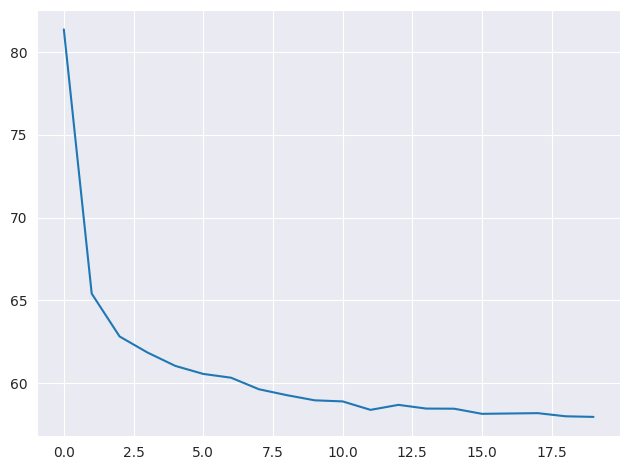

In [9]:
Plot().loss(losses=model.losses)

In [ ]:
# torch.save(model, 'weights_128_64_32_8.pt')

In [11]:
latent_layer_benign_test = model.predict_latent(benign_test_dl)
latent_layer_benign_val = model.predict_latent(benign_val_dl)
latent_layer_attack = model.predict_latent(attacks_test_dl)

  0%|          | 0/35998 [00:00<?, ?it/s]


RuntimeError: The expanded size of the tensor (8) must match the existing size (16) at non-singleton dimension 1.  Target sizes: [16, 8].  Tensor sizes: [16, 16]

In [ ]:
pca = PCA(n_components=2)
pca.fit(np.vstack([latent_layer_benign_test, latent_layer_benign_val, latent_layer_attack]))

In [ ]:
x1, y1  = zip(*list(pca.transform(np.vstack([latent_layer_benign_test, latent_layer_benign_val]))))
x2, y2  = zip(*list(pca.transform(latent_layer_attack)))

In [ ]:
# fig, ax=plt.subplots()
# ax[0].scatter(x2, y2, s=2, alpha=0.25)
# ax[1].scatter(x1, y1, s=2, alpha=0.25)
# plt.show()
fig, ax=plt.subplots()
ax.scatter(x1, y1, s=2, alpha=0.25)
ax.scatter(x2, y2, s=2, alpha=0.25)
plt.show()

In [ ]:
iso_forest = IsolationForest(n_estimators=100, random_state=7, max_features=8, contamination=0.5)
svm = OneClassSVM(kernel='linear')

In [ ]:
iso_forest.fit(latent_layer_benign_test)

In [ ]:
print(pd.Series(iso_forest.predict(latent_layer_attack)).value_counts())
print(pd.Series(iso_forest.predict(latent_layer_benign_test)).value_counts())

In [ ]:
reco_benign_test = np.array(model.reconstruct(benign_test_dl))
reco_benign_val = np.array(model.reconstruct(benign_val_dl))
reco_attack = np.array(model.reconstruct(attacks_test_dl))

In [ ]:
reco_loss_benign_test = reco_benign_test - np.array(benign_test_dl.dataset).squeeze()
reco_loss_benign_val = reco_benign_val - np.array(benign_val_dl.dataset).squeeze()
reco_loss_attack = reco_attack - np.array(attacks_dl.dataset).squeeze()


In [ ]:
iso_forest.fit(reco_loss_benign_test)

In [ ]:
print(pd.Series(iso_forest.predict(reco_loss_benign_val)).value_counts())

In [ ]:
print(pd.Series(iso_forest.predict(reco_loss_attack)).value_counts())

In [ ]:
pca = PCA(n_components=2)
pca.fit(dataset.X_np)

In [ ]:
b, a = dataset.label_partition(labels=[1], binary=True)

x1, y1  = zip(*list(pca.transform(b.X_np)))
x2, y2  = zip(*list(pca.transform(a.X_np)))

fig, ax=plt.subplots(ncols=2)
ax[0].scatter(x2, y2, s=2, alpha=0.25)
ax[1].scatter(x1, y1, s=2, alpha=0.25)
plt.show()
# fig, ax=plt.subplots()
# ax.scatter(x1, y1, s=2, alpha=0.25)
# ax.scatter(x2, y2, s=2, alpha=0.25)
plt.show()

In [ ]:
b